# Direct MLP Baseline for American Put Pricing

## Production Dataset, Reproducible PyTorch Pipeline, and Baseline Evaluation

**SoftUni Deep Learning Final Project**  
**Notebook:** `04_direct_mlp_pricer.ipynb`

This notebook introduces the first deep-learning model in the project. The model receives only the five normalized pricing inputs and predicts the normalized American put value directly. It is intentionally conventional: its purpose is to establish a credible baseline that the later early-exercise-premium and financially constrained models must outperform.

The production design contains **1,450,000 observations**:

- 1,000,000 core-domain observations;
- 250,000 boundary-focused observations;
- four out-of-domain sets with 50,000 observations each.

As a reminder, the large-scale pricing was performed by `scripts/generate_production_dataset.py`, which we activated after the pilot data audit in Notebook 03, and not inside this notebook. 

The path of the project's deep learning path and, respectively, of the current notebook begins only after the `Parquet` files and production manifest have been generated - they contain the dataset.

## 1. Research objective

The direct model estimates

$$
\widehat y = f_\theta(x),
\qquad
x=\left[\log(S/K),T,r,q,\sigma\right],
\qquad
y=\frac{V_A}{K}.
$$

It does not receive European price, intrinsic value, continuation value, early-exercise premium, or the exercise label. Those variables are withheld because they are reserved for later financially structured models.

The direct model is evaluated against the simplest analytical proxy:

$$
\widehat V_A = V_E.
$$

The goal of this first part is to demonstrate that the neural model can materially improve on this Black–Scholes proxy while its financial violations and out-of-domain weaknesses remain visible.

In [1]:
from pathlib import Path
import json
import sys
import time
import subprocess
from collections.abc import Mapping
import shutil

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torchinfo import summary

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.torch_datasets import (
    AmericanOptionDataset,
    DIRECT_TARGET_COLUMN,
    FEATURE_COLUMNS,
    LoaderConfig,
    create_regression_loader,
    fit_feature_scaler,
    load_feature_scaler,
    read_parquet_components,
    save_feature_scaler,
)

from src.data.json_export import _write_export_json

from src.evaluation.financial_checks import financial_bound_report
from src.evaluation.regression_metrics import (
    compare_models,
    regression_metrics,
    segmented_regression_metrics,
)
from src.models.direct_pricer import DirectAmericanPutMLP, DirectMLPConfig
from src.training.checkpointing import load_checkpoint, save_json
from src.training.loops import (
    TrainingConfig,
    fit_regression_model,
    predict_regression_model,
    set_global_seed,
)

## 2. Paths, device, and reproducibility configuration

The production dataset is versioned with DVC and stored in the project’s dedicated R2 storage. Git tracks the code, DVC metadata, and manifests, while the large Parquet files and model artifacts remain outside the repository.

After cloning the project, the required data can be restored with:

```bash
dvc pull
```

This keeps the dataset reproducible without committing approximately 1.45 million observations directly to Git.

The cell below defines the production-data paths, training-artifact directory, random seed, and execution device. CUDA is used when available, because the remaining notebooks contain model training rather than CPU-based data preparation.

`FORCE_TRAIN` controls whether the model is trained again:

* `False` reuses an existing compatible training package when all required artifacts are present and the completion manifest matches the notebook and training profile;
* `True` forces a new training run and replaces the existing artifacts.

The default should remain:

```python
FORCE_TRAIN = False
```

This avoids repeating an expensive GPU run when a complete model package has already been restored through DVC or generated previously.

`TRAINING_PROFILE` identifies the selected experiment configuration. An existing model is reused only when its manifest was produced by the same notebook and with the same profile. Missing, incomplete, or incompatible artifacts trigger training even when `FORCE_TRAIN` is `False`.

The training manifest is written only after all required artifacts have been saved successfully. It therefore acts as a completion marker rather than merely recording that training was started.


In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "generated"
MANIFEST_PATH = PROJECT_ROOT / "data" / "manifests" / "production_dataset_manifest.json"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "direct_mlp"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CORE_PATHS = [
    DATA_DIR / "american_put_core.parquet",
    DATA_DIR / "american_put_boundary.parquet",
]
OOD_PATHS = {
    "high_volatility": DATA_DIR / "american_put_ood_high_volatility.parquet",
    "extreme_moneyness": DATA_DIR / "american_put_ood_extreme_moneyness.parquet",
    "long_maturity": DATA_DIR / "american_put_ood_long_maturity.parquet",
    "rate_dividend": DATA_DIR / "american_put_ood_rate_dividend.parquet",
}

#This is a very important config setting!
#Keep False if model has been trained already
#Set to True if you desire to train the model
FORCE_TRAIN = False
TRAINING_PROFILE = "full"

SEED = 42
set_global_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")

def inspect_training_artifacts(
    manifest_path,
    required_paths,
    *,
    expected_notebook,
    expected_profile,
):
    """Return whether a complete, compatible training package is available."""
    missing = [
        path
        for path in required_paths
        if not path.is_file() or path.stat().st_size == 0
    ]
    if missing:
        return False, "missing: " + ", ".join(path.name for path in missing)

    if not manifest_path.is_file():
        return False, f"missing: {manifest_path.name}"

    try:
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as exc:
        return False, f"invalid manifest: {exc}"

    if manifest.get("status") != "complete":
        return False, "manifest status is not complete"
    if manifest.get("notebook") != expected_notebook:
        return False, "manifest belongs to another notebook"
    if manifest.get("training_profile") != expected_profile:
        return False, "training profile does not match"

    return True, "complete compatible package found"


def write_training_manifest(path, payload):
    """Write the completion marker last and atomically."""
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(
        json.dumps(payload, indent=2),
        encoding="utf-8",
    )
    temporary.replace(path)

Device: cpu
CUDA available: False


In [3]:
required_paths = [
    *CORE_PATHS,
    *OOD_PATHS.values(),
    MANIFEST_PATH,
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

if missing_paths:
    print("Production dataset is missing.")
    print("Starting production-data generation...\n")

    subprocess.run(
        [
            sys.executable,
            str(PROJECT_ROOT / "scripts" / "generate_production_dataset.py"),
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )

# Verify that generation completed successfully
missing_paths = [
    path for path in required_paths
    if not path.exists()
]

if missing_paths:
    missing_text = "\n".join(
        f"- {path}" for path in missing_paths
    )
    raise FileNotFoundError(
        "Production generation finished, but required files "
        f"are still missing:\n{missing_text}"
    )

manifest = json.loads(
    MANIFEST_PATH.read_text(encoding="utf-8")
)

assert (
    manifest["observed_total_observations"]
    == 1_450_000
)

manifest["components"]

[{'name': 'core',
  'path': 'D:\\Users\\kamen.dimitrov\\Desktop\\SOFTUNI\\AI_and_ML_upskill_program\\Deep_Learning\\deep_learning_american_option_pricing\\data\\generated\\american_put_core.parquet',
  'observations': 1000000,
  'start_id': 0,
  'end_id': 999999,
  'split_counts': {'train': 699741, 'validation': 150146, 'test': 150113},
  'exercise_count': 104626,
  'floor_adjustment_count': 142474,
  'max_floor_adjustment': 0.043632871873501955,
  'sha256': '8e5390f56ca056c00c4c176bb728be80298585820e07e09e69e67e57ec8a5476'},
 {'name': 'boundary',
  'path': 'D:\\Users\\kamen.dimitrov\\Desktop\\SOFTUNI\\AI_and_ML_upskill_program\\Deep_Learning\\deep_learning_american_option_pricing\\data\\generated\\american_put_boundary.parquet',
  'observations': 250000,
  'start_id': 1000000,
  'end_id': 1249999,
  'split_counts': {'train': 174771, 'test': 37698, 'validation': 37531},
  'exercise_count': 195114,
  'floor_adjustment_count': 3199,
  'max_floor_adjustment': 0.0027483793961486924,
  'sha

## 3. Frozen data splits

The core and boundary components contain deterministic class-aware split labels. The split is assigned from immutable sample identifiers and the exercise class using a fixed 64-bit hash. This avoids loading all 1.25 million in-domain observations merely to allocate them, while preserving the exercise-class proportions in expectation.

The feature scaler is fitted exclusively on the training set.

In [4]:
MODEL_COLUMNS = [
    "sample_id",
    "component",
    "split",
    *FEATURE_COLUMNS,
    DIRECT_TARGET_COLUMN,
    "normalized_european_price",
    "strike",
    "intrinsic_value",
    "european_price",
    "moneyness",
    "exercise_now",
    "boundary_distance_normalized",
]

train_frame = read_parquet_components(
    CORE_PATHS,
    columns=MODEL_COLUMNS,
    split="train",
)
validation_frame = read_parquet_components(
    CORE_PATHS,
    columns=MODEL_COLUMNS,
    split="validation",
)
test_frame = read_parquet_components(
    CORE_PATHS,
    columns=MODEL_COLUMNS,
    split="test",
)

split_summary = pd.DataFrame(
    {
        "observations": {
            "train": len(train_frame),
            "validation": len(validation_frame),
            "test": len(test_frame),
        },
        "exercise_rate": {
            "train": train_frame["exercise_now"].mean(),
            "validation": validation_frame["exercise_now"].mean(),
            "test": test_frame["exercise_now"].mean(),
        },
    }
)
split_summary

,observations,exercise_rate
train,874512,0.239707
validation,187677,0.239523
test,187811,0.240454


The observed shares should be close to 70%, 15%, and 15%. Exact equality is not necessary because assignment is hash-based rather than based on a global in-memory permutation. What matters is that the split is deterministic, disjoint, and stable across every model notebook.

## 4. Black–Scholes proxy baseline

Before training, the European normalized price is evaluated as a proxy for the American target. Its error is exactly the normalized early-exercise premium. This is the economically relevant baseline: a neural model that does not improve materially on it adds little value.

In [5]:
baseline_metrics = regression_metrics(
    test_frame[DIRECT_TARGET_COLUMN],
    test_frame["normalized_european_price"],
)
pd.Series(baseline_metrics, name="Black–Scholes proxy").to_frame()

,Black–Scholes proxy
observations,187811.000000
mae,0.013398
rmse,0.027384
median_absolute_error,0.002710
max_absolute_error,0.188955
mean_error,-0.013398
r2,0.971395
within_0.001,0.390595
within_0.005,0.583757
within_0.01,0.690039


## 5. Training-only feature scaling and tensor datasets

The five inputs have different units and numerical scales. Standardization improves optimization but is fitted only on training observations to prevent leakage.

In [6]:
SCALER_PATH = ARTIFACT_DIR / "feature_scaler.joblib"
CHECKPOINT_PATH = ARTIFACT_DIR / "best_direct_mlp.pt"
HISTORY_PATH = ARTIFACT_DIR / "training_history.csv"
MODEL_CONFIG_PATH = ARTIFACT_DIR / "model_config.json"
TRAINING_CONFIG_PATH = ARTIFACT_DIR / "training_config.json"
TRAINING_MANIFEST_PATH = ARTIFACT_DIR / "training_complete.json"

required_training_outputs = [
    CHECKPOINT_PATH,
    HISTORY_PATH,
    MODEL_CONFIG_PATH,
    TRAINING_CONFIG_PATH,
    SCALER_PATH,
]

training_outputs_available, availability_reason = inspect_training_artifacts(
    TRAINING_MANIFEST_PATH,
    required_training_outputs,
    expected_notebook="04_direct_mlp_pricer",
    expected_profile=TRAINING_PROFILE,
)

RUN_TRAINING = FORCE_TRAIN or not training_outputs_available

print(f"Force training:             {FORCE_TRAIN}")
print(f"Training outputs available: {training_outputs_available}")
print(f"Decision:                   {'train' if RUN_TRAINING else 'load'}")
print(f"Artifact check:             {availability_reason}")

if RUN_TRAINING:
    # A new model must use a scaler fitted only on the current training data.
    feature_scaler = fit_feature_scaler(
        train_frame,
        feature_columns=FEATURE_COLUMNS,
    )
    save_feature_scaler(
        feature_scaler,
        SCALER_PATH,
    )
    print(f"Fitted and saved training scaler: {SCALER_PATH}")
else:
    # The saved checkpoint must be paired with the scaler used during training.
    feature_scaler = load_feature_scaler(SCALER_PATH)
    print(f"Loaded existing training scaler: {SCALER_PATH}")

train_dataset = AmericanOptionDataset(
    train_frame,
    scaler=feature_scaler,
)
validation_dataset = AmericanOptionDataset(
    validation_frame,
    scaler=feature_scaler,
)
test_dataset = AmericanOptionDataset(
    test_frame,
    scaler=feature_scaler,
)

LOADER_CONFIG = LoaderConfig(
    batch_size=1024,
    num_workers=0,
    pin_memory=True,
    seed=SEED,
)

train_loader = create_regression_loader(
    train_dataset,
    config=LOADER_CONFIG,
    shuffle=True,
    drop_last=True,
)
validation_loader = create_regression_loader(
    validation_dataset,
    config=LOADER_CONFIG,
    shuffle=False,
)
test_loader = create_regression_loader(
    test_dataset,
    config=LOADER_CONFIG,
    shuffle=False,
)

first_batch = next(iter(train_loader))

{
    "training_action": "train" if RUN_TRAINING else "load",
    "scaler_path": str(SCALER_PATH),
    "feature_batch_shape": tuple(first_batch["features"].shape),
    "target_batch_shape": tuple(first_batch["target"].shape),
    "feature_dtype": str(first_batch["features"].dtype),
    "target_dtype": str(first_batch["target"].dtype),
}

Force training:             False
Training outputs available: True
Decision:                   load
Artifact check:             complete compatible package found
Loaded existing training scaler: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\artifacts\direct_mlp\feature_scaler.joblib


C:\Users\kamen.dimitrov\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


{'training_action': 'load',
 'scaler_path': 'D:\\Users\\kamen.dimitrov\\Desktop\\SOFTUNI\\AI_and_ML_upskill_program\\Deep_Learning\\deep_learning_american_option_pricing\\artifacts\\direct_mlp\\feature_scaler.joblib',
 'feature_batch_shape': (1024, 5),
 'target_batch_shape': (1024, 1),
 'feature_dtype': 'torch.float32',
 'target_dtype': 'torch.float32'}

## 6. Direct MLP architecture

The architecture is deliberately strong but conventional:

```text
Input(5)
→ Linear(128) → BatchNorm → SiLU
→ Linear(128) → BatchNorm → SiLU
→ Linear(64)  → SiLU
→ Linear(32)  → SiLU
→ Linear(1)   → Softplus
```

`Softplus` prevents negative option values. It does not enforce the intrinsic-value or European-value lower bounds; those violations remain part of the baseline evaluation.

In [7]:
MODEL_CONFIG = DirectMLPConfig(
    input_features=len(FEATURE_COLUMNS),
    hidden_sizes=(128, 128, 64, 32),
    batch_norm_after=(0, 1),
    output_activation="softplus",
)
model = DirectAmericanPutMLP(MODEL_CONFIG).to(DEVICE)

print(f"Trainable parameters: {model.trainable_parameter_count:,}")
summary(model, input_size=(LOADER_CONFIG.batch_size, len(FEATURE_COLUMNS)))

Trainable parameters: 28,161


Layer (type:depth-idx)                   Output Shape              Param #
DirectAmericanPutMLP                     [1024, 1]                 --
├─Sequential: 1-1                        [1024, 1]                 --
│    └─Linear: 2-1                       [1024, 128]               768
│    └─BatchNorm1d: 2-2                  [1024, 128]               256
│    └─SiLU: 2-3                         [1024, 128]               --
│    └─Linear: 2-4                       [1024, 128]               16,512
│    └─BatchNorm1d: 2-5                  [1024, 128]               256
│    └─SiLU: 2-6                         [1024, 128]               --
│    └─Linear: 2-7                       [1024, 64]                8,256
│    └─SiLU: 2-8                         [1024, 64]                --
│    └─Linear: 2-9                       [1024, 32]                2,080
│    └─SiLU: 2-10                        [1024, 32]                --
│    └─Linear: 2-11                      [1024, 1]                 33
│ 

## 7. Training protocol

Smooth L1 loss is used as the primary objective because the pricing domain includes near-zero values, deep-in-the-money contracts, and potentially larger errors around the stopping boundary. AdamW, validation-based learning-rate reduction, early stopping, gradient clipping, and mixed precision on CUDA are applied consistently.

**Execution control.** `FORCE_TRAIN = True` in the configuration cell above runs the full training stage and rebuilds its artifacts. After one successful run, set it to `False`; the notebook then loads the saved checkpoint and training history when the completion manifest and all required files are present. Missing or incompatible artifacts automatically trigger training.


In [8]:
TRAINING_CONFIG = TrainingConfig(
    epochs=100,
    learning_rate=1e-3,
    weight_decay=1e-5,
    early_stopping_patience=10,
    scheduler_patience=4,
    scheduler_factor=0.5,
    min_learning_rate=1e-6,
    gradient_clip_norm=1.0,
    mixed_precision=True,
    seed=SEED,
)

loss_fn = nn.SmoothL1Loss()

if RUN_TRAINING:
    # The completion marker must exist only after every artifact is saved.
    TRAINING_MANIFEST_PATH.unlink(missing_ok=True)

    training_started = time.perf_counter()

    history = fit_regression_model(
        model,
        train_loader,
        validation_loader,
        loss_fn=loss_fn,
        device=DEVICE,
        checkpoint_path=CHECKPOINT_PATH,
        config=TRAINING_CONFIG,
        model_config=MODEL_CONFIG.to_dict(),
    )

    training_runtime_seconds = time.perf_counter() - training_started

    history.to_csv(HISTORY_PATH, index=False)
    save_json(MODEL_CONFIG.to_dict(), MODEL_CONFIG_PATH)
    save_json(TRAINING_CONFIG.to_dict(), TRAINING_CONFIG_PATH)

    best_checkpoint = load_checkpoint(
        CHECKPOINT_PATH,
        map_location="cpu",
    )

    epochs_completed = int(history["epoch"].max())
    best_epoch = int(best_checkpoint["epoch"])

    write_training_manifest(
        TRAINING_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": "04_direct_mlp_pricer",
            "training_profile": TRAINING_PROFILE,
            "requested_epochs": int(TRAINING_CONFIG.epochs),
            "epochs_completed": epochs_completed,
            "best_epoch": best_epoch,
            "early_stopped": (
                epochs_completed < int(TRAINING_CONFIG.epochs)
            ),
            "best_validation_loss": float(
                best_checkpoint["best_validation_loss"]
            ),
            "training_runtime_seconds": float(
                training_runtime_seconds
            ),
            "checkpoint": CHECKPOINT_PATH.name,
            "history": HISTORY_PATH.name,
            "scaler": SCALER_PATH.name,
            "model_config": MODEL_CONFIG_PATH.name,
            "training_config": TRAINING_CONFIG_PATH.name,
        },
    )

    print(
        f"Training complete. Best epoch: {best_epoch}; "
        f"epochs completed: {epochs_completed}."
    )

else:
    history = pd.read_csv(HISTORY_PATH)
    print("Existing compatible training package reused.")


# Always load the best saved checkpoint, regardless of whether the
# model was trained now or restored from existing artifacts.
best_checkpoint = load_checkpoint(
    CHECKPOINT_PATH,
    map_location=DEVICE,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)
model.to(DEVICE)
model.eval()

print(
    f"Loaded best checkpoint from epoch "
    f"{int(best_checkpoint['epoch'])}."
)

history.tail()

Existing compatible training package reused.
Loaded best checkpoint from epoch 42.


,epoch,train_loss,train_mae,validation_loss,validation_mae,learning_rate,epoch_seconds
47,48,0.000011,0.003535,1.804587e-06,0.001562,0.000063,8.184945
48,49,0.000011,0.003521,8.532192e-07,0.000910,0.000063,8.177488
49,50,0.000010,0.003367,1.009445e-06,0.001107,0.000063,8.357619
50,51,0.000011,0.003482,7.229886e-07,0.000867,0.000063,8.231267
51,52,0.000011,0.003545,9.207835e-07,0.001046,0.000031,8.280128


## 8. Learning curves

Training and validation curves are reviewed together. The selected checkpoint is the epoch with the lowest validation loss, not the final epoch.

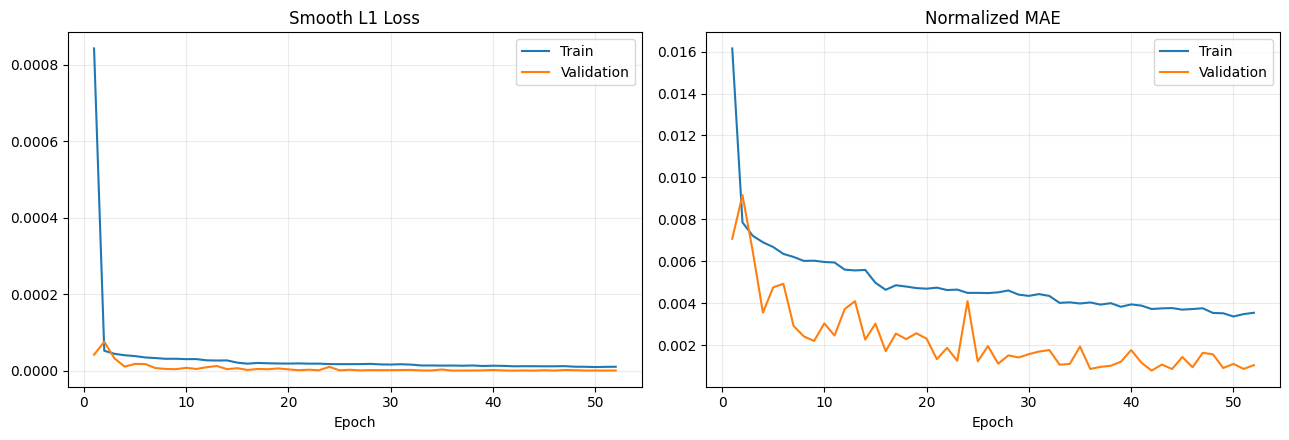

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history["epoch"], history["train_loss"], label="Train")
axes[0].plot(history["epoch"], history["validation_loss"], label="Validation")
axes[0].set_title("Smooth L1 Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history["epoch"], history["train_mae"], label="Train")
axes[1].plot(history["epoch"], history["validation_mae"], label="Validation")
axes[1].set_title("Normalized MAE")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. In-domain test performance

The best checkpoint is reloaded before test evaluation. The test set has not influenced scaling, optimization, checkpoint selection, or learning-rate decisions.

In [10]:
checkpoint = load_checkpoint(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_predictions = predict_regression_model(
    model,
    test_loader,
    device=DEVICE,
)
test_evaluation = test_frame.merge(
    test_predictions,
    on="sample_id",
    validate="one_to_one",
)

comparison = compare_models(
    test_evaluation[DIRECT_TARGET_COLUMN],
    {
        "Black–Scholes proxy": test_evaluation["normalized_european_price"],
        "Direct MLP": test_evaluation["prediction"],
    },
)
comparison

,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
model,,,,,,,,,,,
Black–Scholes proxy,187811.0,0.013398,0.027384,0.002710,0.188955,-0.013398,0.971395,0.390595,0.583757,0.690039,0.917438
Direct MLP,187811.0,0.000782,0.001146,0.000548,0.019201,-0.000128,0.999950,0.741927,0.995107,0.999766,1.000000


In [11]:
evaluation_summary = {
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "best_validation_loss": float(checkpoint["best_validation_loss"]),
    "black_scholes_proxy": baseline_metrics,
    "direct_mlp": regression_metrics(
        test_evaluation[DIRECT_TARGET_COLUMN],
        test_evaluation["prediction"],
    ),
}
save_json(evaluation_summary, ARTIFACT_DIR / "evaluation_summary.json")

WindowsPath('D:/Users/kamen.dimitrov/Desktop/SOFTUNI/AI_and_ML_upskill_program/Deep_Learning/deep_learning_american_option_pricing/artifacts/direct_mlp/evaluation_summary.json')

## 10. Segmented error analysis

Aggregate accuracy can conceal concentrated weaknesses. Errors are therefore evaluated by moneyness, maturity, volatility, exercise status, and distance from the stopping boundary.

In [12]:
test_evaluation["moneyness_bucket"] = pd.cut(
    test_evaluation["moneyness"],
    bins=[0.0, 0.75, 0.90, 1.10, 1.25, np.inf],
    labels=["deep ITM", "ITM", "near ATM", "OTM", "deep OTM"],
)
test_evaluation["maturity_bucket"] = pd.cut(
    test_evaluation["time_to_maturity"],
    bins=[0.0, 0.25, 0.75, 1.25, np.inf],
    labels=["short", "medium", "long", "very long"],
)
test_evaluation["volatility_bucket"] = pd.cut(
    test_evaluation["volatility"],
    bins=[0.0, 0.20, 0.40, 0.60, np.inf],
    labels=["low", "moderate", "high", "very high"],
)
test_evaluation["exercise_region"] = np.where(
    test_evaluation["exercise_now"], "exercise", "continue"
)

segmented_regression_metrics(
    test_evaluation,
    actual_column=DIRECT_TARGET_COLUMN,
    prediction_column="prediction",
    segment_column="moneyness_bucket",
)

,segment,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
0,deep ITM,65461.0,0.000825,0.001090,0.000648,0.011382,-0.000390,0.999802,0.684239,0.999236,0.999985,1.0
1,ITM,29422.0,0.000863,0.001183,0.000628,0.010490,-0.000132,0.999751,0.683128,0.998063,0.999966,1.0
2,near ATM,32521.0,0.000946,0.001537,0.000564,0.019201,-0.000096,0.999751,0.724732,0.980136,0.999231,1.0
3,OTM,22601.0,0.000716,0.001108,0.000512,0.014937,-0.000154,0.999848,0.805318,0.995000,0.999248,1.0
4,deep OTM,37806.0,0.000542,0.000780,0.000399,0.008855,0.000315,0.999897,0.864466,0.998598,1.000000,1.0


## 11. Financial consistency

The `Softplus` output prevents negative values, but it does not guarantee that the direct model remains above intrinsic value or above the corresponding European price. These violations are measured rather than repaired after prediction.

In [13]:
financial_report = financial_bound_report(
    test_evaluation,
    normalized_prediction_column="prediction",
)
financial_report

,check,violations,violation_rate,max_violation,mean_violation_when_failed
0,negative_price,0,0.000000,0.000000,0.000000
1,below_intrinsic,32993,0.175671,1.435868,0.113583
2,below_european,25817,0.137463,1.132807,0.086594


## 12. Out-of-domain evaluation

The four OOD datasets were excluded from training, validation, feature scaling, and checkpoint selection. They test how the model behaves when one part of the pricing domain moves beyond the ranges used for training.

The direct MLP is evaluated against the Black–Scholes European proxy on every OOD set. This matters because deterioration alone is not enough to judge the model: the neural network may perform worse than it does in-domain but still provide useful improvement over the analytical baseline.

The evaluation reports:

* normalized and price-unit errors for both models;
* deterioration relative to each model’s in-domain MAE;
* the direct MLP’s improvement over the Black–Scholes proxy;
* negative-price, intrinsic-value, and European-value violations.

The OOD results are diagnostic rather than evidence of general applicability. In particular, the long-maturity set tests extrapolation from the training range of up to two years into maturities between two and four years.

In [14]:
ood_direct_rows = []
ood_comparison_rows = []
ood_financial_rows = []
ood_evaluations = {}

for ood_name, path in OOD_PATHS.items():
    frame = read_parquet_components(
        [path],
        columns=MODEL_COLUMNS,
        split=None,
    )

    dataset = AmericanOptionDataset(
        frame,
        scaler=feature_scaler,
    )
    loader = create_regression_loader(
        dataset,
        config=LOADER_CONFIG,
        shuffle=False,
    )

    prediction = predict_regression_model(
        model,
        loader,
        device=DEVICE,
    )

    evaluated = frame.merge(
        prediction,
        on="sample_id",
        validate="one_to_one",
    )

    # Keep the evaluated frames available for later diagnostics.
    ood_evaluations[ood_name] = evaluated

    normalized_truth = evaluated[
        DIRECT_TARGET_COLUMN
    ].to_numpy(dtype=np.float64)

    strike = evaluated["strike"].to_numpy(
        dtype=np.float64
    )
    price_truth = normalized_truth * strike

    model_predictions = {
        "Black–Scholes proxy": (
            evaluated["normalized_european_price"]
            .to_numpy(dtype=np.float64)
        ),
        "Direct MLP": (
            evaluated["prediction"]
            .to_numpy(dtype=np.float64)
        ),
    }

    for model_name, normalized_prediction in model_predictions.items():
        normalized_metrics = regression_metrics(
            normalized_truth,
            normalized_prediction,
        )

        price_prediction = normalized_prediction * strike
        price_metrics = regression_metrics(
            price_truth,
            price_prediction,
        )

        in_domain_mae = float(
            comparison.loc[model_name, "mae"]
        )

        ood_comparison_rows.append(
            {
                "ood_set": ood_name,
                "model": model_name,
                "observations": int(len(evaluated)),
                "normalized_mae": normalized_metrics["mae"],
                "normalized_rmse": normalized_metrics["rmse"],
                "price_mae": price_metrics["mae"],
                "price_rmse": price_metrics["rmse"],
                "price_median_absolute_error": (
                    price_metrics["median_absolute_error"]
                ),
                "price_max_absolute_error": (
                    price_metrics["max_absolute_error"]
                ),
                "mean_price_error": price_metrics["mean_error"],
                "r2": normalized_metrics["r2"],
                "mae_multiple_vs_in_domain": (
                    normalized_metrics["mae"]
                    / in_domain_mae
                ),
            }
        )

        prediction_column = (
            "normalized_european_price"
            if model_name == "Black–Scholes proxy"
            else "prediction"
        )

        bound_report = financial_bound_report(
            evaluated,
            normalized_prediction_column=prediction_column,
        ).copy()

        bound_report.insert(0, "model", model_name)
        bound_report.insert(0, "ood_set", ood_name)

        ood_financial_rows.append(bound_report)

    # Preserve the original direct-only result structure because it is
    # consumed by the later export cell.
    ood_direct_rows.append(
        {
            "ood_set": ood_name,
            **regression_metrics(
                normalized_truth,
                evaluated["prediction"],
            ),
        }
    )


# Existing direct-only table retained for downstream exports.
ood_results = (
    pd.DataFrame(ood_direct_rows)
    .set_index("ood_set")
)

# Full OOD comparison between the analytical proxy and the MLP.
ood_model_comparison = pd.DataFrame(
    ood_comparison_rows
).sort_values(
    ["ood_set", "model"]
).reset_index(drop=True)

# Financial consistency for both models in every OOD regime.
ood_financial_report = pd.concat(
    ood_financial_rows,
    ignore_index=True,
)


price_mae_table = ood_model_comparison.pivot(
    index="ood_set",
    columns="model",
    values="price_mae",
)

direct_details = (
    ood_model_comparison.loc[
        ood_model_comparison["model"] == "Direct MLP",
        [
            "ood_set",
            "price_rmse",
            "price_max_absolute_error",
            "mean_price_error",
            "r2",
            "mae_multiple_vs_in_domain",
        ],
    ]
    .set_index("ood_set")
)

ood_summary = price_mae_table.join(
    direct_details
)

ood_summary["direct_improvement_vs_black_scholes"] = (
    1.0
    - (
        ood_summary["Direct MLP"]
        / ood_summary["Black–Scholes proxy"]
    )
)

ood_summary = ood_summary.rename(
    columns={
        "Black–Scholes proxy": "black_scholes_price_mae",
        "Direct MLP": "direct_mlp_price_mae",
        "price_rmse": "direct_mlp_price_rmse",
        "price_max_absolute_error": (
            "direct_mlp_max_absolute_error"
        ),
        "mean_price_error": "direct_mlp_mean_error",
        "r2": "direct_mlp_r2",
        "mae_multiple_vs_in_domain": (
            "direct_mlp_mae_multiple_vs_in_domain"
        ),
    }
)

display(ood_summary)
display(ood_financial_report)

,black_scholes_price_mae,direct_mlp_price_mae,direct_mlp_price_rmse,direct_mlp_max_absolute_error,direct_mlp_mean_error,direct_mlp_r2,direct_mlp_mae_multiple_vs_in_domain,direct_improvement_vs_black_scholes
ood_set,,,,,,,,
extreme_moneyness,1.606745,1.199265,2.031865,13.288258,-1.181585,0.995443,15.342281,0.253606
high_volatility,0.688740,0.922117,1.459984,11.233580,-0.084651,0.989659,11.796701,-0.338847
long_maturity,2.240608,4.602629,8.706125,43.575916,-4.226703,0.703781,58.881738,-1.054188
rate_dividend,2.065520,1.151851,1.755807,8.930409,0.227170,0.985990,14.735709,0.442343


,ood_set,model,check,violations,violation_rate,max_violation,mean_violation_when_failed
0,high_volatility,Black–Scholes proxy,negative_price,0,0.00000,0.000000e+00,0.000000
1,high_volatility,Black–Scholes proxy,below_intrinsic,396,0.00792,1.196814e+00,0.243420
2,high_volatility,Black–Scholes proxy,below_european,0,0.00000,7.105427e-15,0.000000
3,high_volatility,Direct MLP,negative_price,0,0.00000,0.000000e+00,0.000000
4,high_volatility,Direct MLP,below_intrinsic,215,0.00430,7.611488e+00,1.402859
5,high_volatility,Direct MLP,below_european,16266,0.32532,7.450638e+00,0.848787
6,extreme_moneyness,Black–Scholes proxy,negative_price,0,0.00000,0.000000e+00,0.000000
7,extreme_moneyness,Black–Scholes proxy,below_intrinsic,19987,0.39974,1.696269e+01,3.778127
8,extreme_moneyness,Black–Scholes proxy,below_european,0,0.00000,7.105427e-15,0.000000
9,extreme_moneyness,Direct MLP,negative_price,0,0.00000,0.000000e+00,0.000000


## 13. Neural inference benchmark

The benchmark measures only the post-training forward-pass cost. Data generation and model training are reported separately and are not hidden in the inference comparison.

In [15]:
@torch.inference_mode()
def benchmark_inference(model, features, device, repeats=5):
    model.eval()
    features = features.to(device)
    if device.type == "cuda":
        torch.cuda.synchronize()
    timings = []
    for _ in range(repeats):
        started = time.perf_counter()
        _ = model(features)
        if device.type == "cuda":
            torch.cuda.synchronize()
        timings.append(time.perf_counter() - started)
    return {
        "observations": len(features),
        "median_seconds": float(np.median(timings)),
        "observations_per_second": float(len(features) / np.median(timings)),
    }

benchmark_rows = []
for size in (1_000, 10_000, 100_000):
    source = test_dataset.features[: min(size, len(test_dataset))]
    benchmark_rows.append(benchmark_inference(model, source, DEVICE))

pd.DataFrame(benchmark_rows)

,observations,median_seconds,observations_per_second
0,1000,0.008232,121477.162399
1,10000,0.044832,223053.965454
2,100000,0.263218,379912.939222


## 14. Interim hypothesis assessment

Notebook 04 provides the first formal evidence for **H1**. The hypothesis is supported only if the direct MLP materially improves on the Black–Scholes proxy across the full in-domain test set and not merely in one narrow segment.

The speed component of **H5** remains preliminary until the later models are benchmarked under identical conditions.

The expected financial violations and OOD deterioration documented here motivate the early-exercise-premium architecture developed in Notebook 05.

## 15. Reproducibility checkpoint

The following artifacts are produced:

```text
artifacts/direct_mlp/
├── best_direct_mlp.pt
├── feature_scaler.joblib
├── training_history.csv
├── model_config.json
├── training_config.json
├── training_complete.json
└── evaluation_summary.json
```

## Canonical final-result exports

This cell publishes the normalized artifacts consumed by Notebook 09 and tracked through DVC. Existing research outputs above remain unchanged.


In [16]:
# Canonical Notebook 04 exports for Notebook 09 and DVC.

direct_prediction_columns = [
    column
    for column in (
        "sample_id",
        "split",
        "moneyness",
        "log_moneyness",
        "time_to_maturity",
        "risk_free_rate",
        "dividend_yield",
        "volatility",
        "exercise_now",
        "normalized_european_price",
        "normalized_intrinsic_value",
        DIRECT_TARGET_COLUMN,
        "prediction",
    )
    if column in test_evaluation.columns
]
direct_test_predictions = test_evaluation.loc[
    :,
    direct_prediction_columns,
].copy()
direct_test_predictions = direct_test_predictions.rename(
    columns={"prediction": "direct_mlp_prediction"}
)
direct_test_predictions.to_parquet(
    ARTIFACT_DIR / "test_predictions.parquet",
    index=False,
)

comparison.to_csv(
    ARTIFACT_DIR / "model_comparison.csv",
    index=True,
)

if isinstance(financial_report, pd.DataFrame):
    direct_financial_consistency = financial_report.copy()
elif isinstance(financial_report, pd.Series):
    direct_financial_consistency = (
        financial_report.rename("value").reset_index()
    )
else:
    direct_financial_consistency = pd.DataFrame(
        [_export_json_safe(financial_report)]
    )
direct_financial_consistency.to_csv(
    ARTIFACT_DIR / "financial_consistency.csv",
    index=False,
)

direct_ood_results = ood_results.reset_index()
direct_ood_results.insert(1, "model", "Direct MLP")
direct_ood_results.to_csv(
    ARTIFACT_DIR / "ood_results.csv",
    index=False,
)

runtime_results = pd.DataFrame(benchmark_rows).copy()
runtime_results.insert(0, "model", "Direct MLP")
runtime_results["device"] = str(DEVICE)
runtime_results["seconds_per_observation"] = (
    runtime_results["median_seconds"]
    / runtime_results["observations"]
)
runtime_results.to_csv(
    ARTIFACT_DIR / "runtime_results.csv",
    index=False,
)
_write_export_json(
    ARTIFACT_DIR / "runtime_summary.json",
    {
        "model": "Direct MLP",
        "device": str(DEVICE),
        "records": runtime_results.to_dict(orient="records"),
    },
)

direct_final_metrics = {
    "schema_version": 1,
    "status": "complete",
    "notebook": "04_direct_mlp_pricer",
    "training_profile": TRAINING_PROFILE,
    "selected_model": "Direct MLP",
    "checkpoint": CHECKPOINT_PATH.name,
    "pricing": {
        "black_scholes_proxy": baseline_metrics,
        "direct_mlp": evaluation_summary["direct_mlp"],
    },
    "financial_consistency": (
        direct_financial_consistency.to_dict(orient="records")
    ),
    "ood": direct_ood_results.to_dict(orient="records"),
    "runtime": runtime_results.to_dict(orient="records"),
}
_write_export_json(
    ARTIFACT_DIR / "final_metrics.json",
    direct_final_metrics,
)

print("Canonical Notebook 04 exports saved.")


Canonical Notebook 04 exports saved.


# 16. Conclusion and handoff to Notebook 05

Notebook 04 establishes the direct MLP as a strong in-domain pricing baseline.

The model trained for 52 epochs, with the best checkpoint selected at epoch 42. Learning-rate reductions and early stopping worked as intended, and the validation results do not indicate conventional overfitting.

On the 187,811-observation in-domain test set, the direct MLP reduced normalized MAE from 0.013398 for the Black–Scholes proxy to 0.000782. With strike fixed at 100, this corresponds to a reduction in average pricing error from 1.3398 to 0.0782 price units. RMSE fell from 2.7384 to 0.1146, while $R^2$ increased to 0.999950.

This is sufficient evidence to support **H1**: a conventional MLP can approximate the in-domain American put pricing function materially better than using the European Black–Scholes value as a proxy.

The result is strong, but it is not financially complete.

Although `Softplus` prevents negative predictions, 17.57% of test prices fall below intrinsic value and 13.75% fall below the corresponding European price. The average shortfalls are small, but the violation rates are too high for the direct model to be treated as a financially coherent pricer without additional structure.

The model also remains an interpolator rather than a reliable extrapolator. OOD MAE increases by approximately 12 to 15 times under high volatility, extreme moneyness, and elevated rate/dividend conditions.

Long maturity is the clear failure case. For maturities between two and four years, MAE rises to 4.6026 price units, RMSE to 8.7061, and the maximum error to 43.5759. The mean error of $-4.2267$ shows systematic underpricing rather than isolated outliers. The direct network has learned the pricing surface inside the maturity range it observed, but it has not learned a dependable rule for extending that surface beyond two years.

The outcome of the model training in this workbook, however, gives a green light regarding the further development of the topic of the project. Failure at this point to prove that a direct MLP will outperform the European Black–Scholes proxy when approximating in-domain American put prices would have ended this experiment here. I am now free to move on with the next steps.

## Why Notebook 05 is necessary

The direct model is asked to learn the complete American option value from five inputs. This includes a large component that is already known analytically through the European Black–Scholes price.

Notebook 05 tests whether the learning problem becomes more accurate and financially stable when that known component is removed from the neural target.

It compares:

1. an unconstrained early-exercise-premium model;
2. a non-negative premium model;
3. a residual model built above the full financial floor,

with the same production data, frozen splits, feature scaler, hidden capacity, and evaluation framework.

The key questions are now narrower:

* Does residual learning improve test-set pricing error over the direct MLP?
* Does a non-negative premium eliminate European lower-bound violations?
* Does the full financial-floor formulation eliminate both European and intrinsic-value violations?
* Does separating the known European component reduce the severe long-maturity extrapolation error?

Notebook 04 proves that the neural network can learn the in-domain pricing function. Notebook 05 tests whether the model can do so without repeatedly violating the financial structure of the contract.
